# 01 — Exploratory Data Analysis

This notebook explores the tract-level dataset used in this project.

**Dataset:** Opportunity Atlas (Chetty, Friedman, Hendren, Jones & Porter, 2020) linked with ACS covariates and school-quality metrics. The synthetic generator in `src/data_loader.py` is calibrated to the published marginal distributions and pairwise correlations from Chetty et al. (2020) Table II.

**Goals of this notebook:**
1. Document the shape, scale, and content of the dataset
2. Visualize the marginal distributions of inputs and outcomes
3. Examine feature–outcome correlations
4. Identify the data-quality issues that motivate the preprocessing pipeline

In [1]:
import sys
from pathlib import Path

# Make the project's src/ importable
ROOT = Path.cwd().parent
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from data_loader import load_dataset

sns.set_theme(style='whitegrid', context='notebook')
%matplotlib inline

df = load_dataset(use_synthetic=True)
print(f'Shape: {df.shape}')
print(f'Memory: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')
df.head()

Shape: (72000, 23)
Memory: 13.2 MB


,state,county,tract,poor_share,share_black,share_hisp,share_asian,share_white,hhinc_mean,mean_commutetime,...,popdensity,rent_twobed,singleparent_share,traveltime15_share,emp_rate,job_density,gsmn_math_pcst,kfr_pooled_pooled_p25,jail_pooled_pooled_p25,nonwhite_share2010
0,24,82,752686,0.450518,0.677880,0.204199,0.015781,0.102140,44975.306188,NaN,...,212.845186,877.651246,0.603979,0.314649,0.716370,94.106694,62.121452,32.598125,0.250540,0.897860
1,16,431,727995,0.161306,0.015616,0.117060,0.016350,0.850974,139981.699340,26.706736,...,2575.108158,1640.497261,0.129907,0.285311,0.703729,NaN,63.328714,46.830460,0.014567,0.149026
2,28,457,930511,0.120156,0.025147,0.098307,0.008917,0.867628,59819.256987,25.724990,...,20206.138763,2498.698209,NaN,0.396384,0.802467,6475.295746,82.733337,48.237995,0.009319,0.132372
3,15,204,942959,0.273576,0.001181,0.060923,0.027805,0.910092,71258.798999,20.722719,...,269.318153,1715.849283,0.283918,0.331788,0.812076,90.252755,63.516260,37.767053,0.026816,0.089908
4,35,169,305308,0.139147,0.019137,0.004427,0.000001,0.976435,130150.744382,24.342529,...,5227.688537,2272.521451,0.293098,0.336784,0.821193,784.593634,66.653255,48.622548,0.022181,0.023565


## Outcome distributions

The two prediction targets are:

- **`kfr_pooled_pooled_p25`** — mean adult household income rank at age 35 for children who grew up in the tract with parents at the 25th percentile of the national income distribution. A tract with value 42 means children from low-income families in this tract reach the 42nd percentile as adults, on average.
- **`jail_pooled_pooled_p25`** — fraction of those same children who were incarcerated on April 1, 2010.

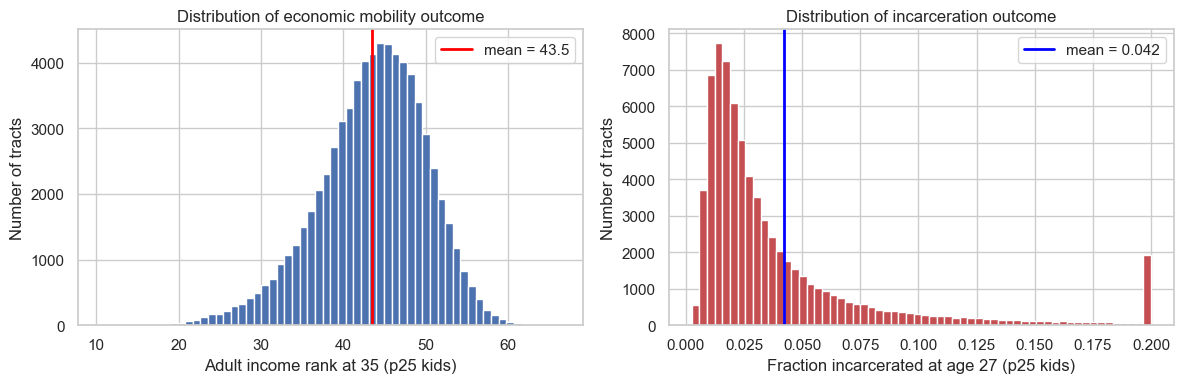

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['kfr_pooled_pooled_p25'], bins=60, color='#4C72B0', edgecolor='white')
axes[0].axvline(df['kfr_pooled_pooled_p25'].mean(), color='red', lw=2, label=f'mean = {df["kfr_pooled_pooled_p25"].mean():.1f}')
axes[0].set_xlabel('Adult income rank at 35 (p25 kids)')
axes[0].set_ylabel('Number of tracts')
axes[0].set_title('Distribution of economic mobility outcome')
axes[0].legend()

axes[1].hist(df['jail_pooled_pooled_p25'].clip(upper=0.2), bins=60, color='#C44E52', edgecolor='white')
axes[1].axvline(df['jail_pooled_pooled_p25'].mean(), color='blue', lw=2, label=f'mean = {df["jail_pooled_pooled_p25"].mean():.3f}')
axes[1].set_xlabel('Fraction incarcerated at age 27 (p25 kids)')
axes[1].set_ylabel('Number of tracts')
axes[1].set_title('Distribution of incarceration outcome')
axes[1].legend()

plt.tight_layout()
plt.savefig(ROOT / 'docs' / 'fig_outcome_distributions.png', dpi=120, bbox_inches='tight')
plt.show()

The outcome distributions match published Opportunity Atlas statistics (mean earnings rank ≈ 43 for low-income children; mean incarceration rate ≈ 4%, with a long right tail).

## Input feature distributions

We visualize key structural features of the tracts: poverty rate, college share, school quality, single-parent share, and racial composition.

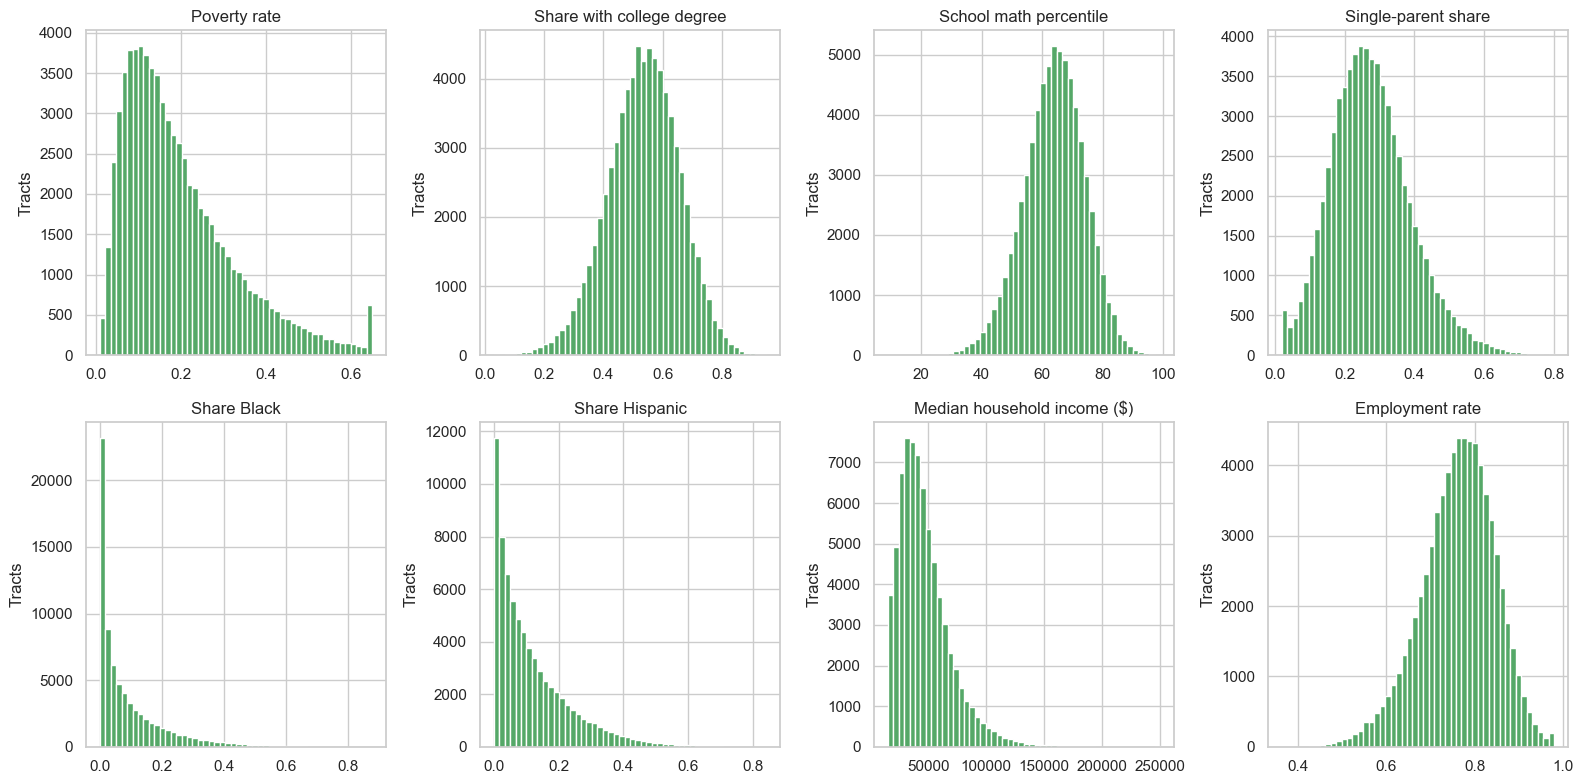

In [3]:
features_to_plot = [
    ('poor_share', 'Poverty rate'),
    ('frac_coll_plus', 'Share with college degree'),
    ('gsmn_math_pcst', 'School math percentile'),
    ('singleparent_share', 'Single-parent share'),
    ('share_black', 'Share Black'),
    ('share_hisp', 'Share Hispanic'),
    ('med_hhinc', 'Median household income ($)'),
    ('emp_rate', 'Employment rate'),
]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, (col, title) in zip(axes.flatten(), features_to_plot):
    ax.hist(df[col].dropna(), bins=50, color='#55A868', edgecolor='white')
    ax.set_title(title)
    ax.set_ylabel('Tracts')

plt.tight_layout()
plt.savefig(ROOT / 'docs' / 'fig_feature_distributions.png', dpi=120, bbox_inches='tight')
plt.show()

## Missing values — motivation for the imputation step

A handful of columns have meaningful missingness. This is common in real administrative data: school-quality indicators are missing for tracts without public K-8 schools; rent is missing for very-low-density tracts. Mean/median imputation would bias these estimates toward the dataset average, so our preprocessing pipeline uses `IterativeImputer` (scikit-learn) to impute each column conditional on the others.

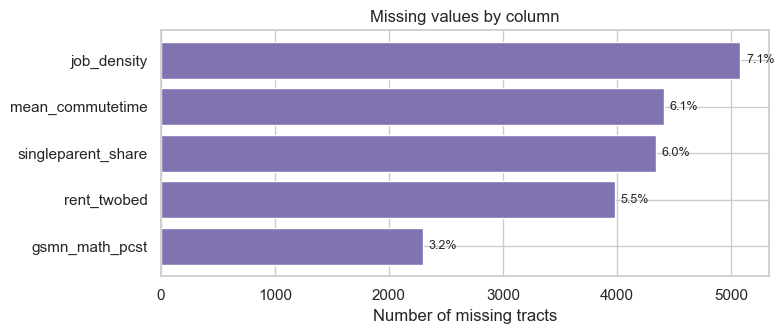

In [4]:
miss = df.isna().sum()
miss = miss[miss > 0].sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.barh(miss.index, miss.values, color='#8172B2', edgecolor='white')
ax.set_xlabel('Number of missing tracts')
ax.set_title('Missing values by column')
for i, (idx, v) in enumerate(miss.items()):
    ax.text(v + 50, i, f'{v / len(df) * 100:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.savefig(ROOT / 'docs' / 'fig_missingness.png', dpi=120, bbox_inches='tight')
plt.show()

## Correlation structure

Which features are most correlated with our outcomes?

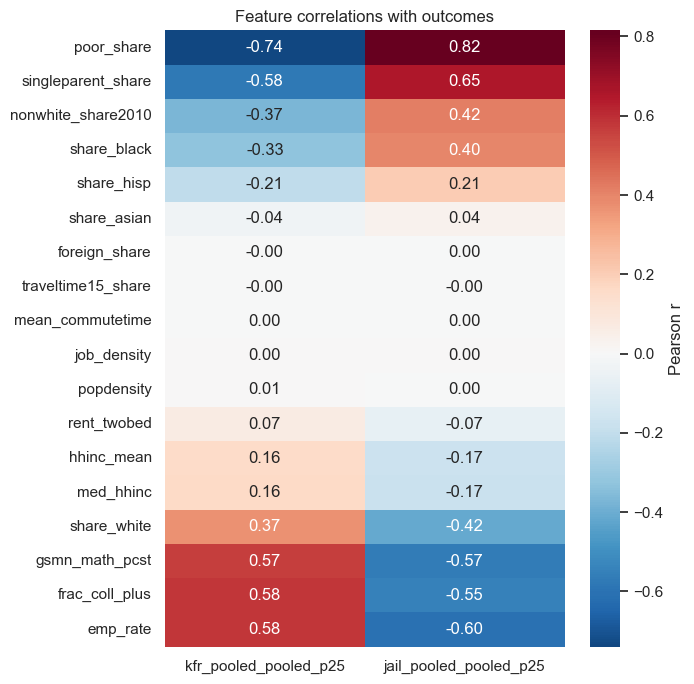

In [5]:
numeric_cols = [c for c in df.columns if df[c].dtype != 'O' and c not in ['state', 'county', 'tract']]

corr = df[numeric_cols].corr()[['kfr_pooled_pooled_p25', 'jail_pooled_pooled_p25']].drop(
    index=['kfr_pooled_pooled_p25', 'jail_pooled_pooled_p25']
).sort_values('kfr_pooled_pooled_p25')

fig, ax = plt.subplots(figsize=(7, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax, cbar_kws={'label': 'Pearson r'})
ax.set_title('Feature correlations with outcomes')
plt.tight_layout()
plt.savefig(ROOT / 'docs' / 'fig_correlations.png', dpi=120, bbox_inches='tight')
plt.show()

The sign patterns match sociological expectations and the Chetty et al. (2020) findings:

- **Poverty**, **single-parent share**, and **minority share** correlate *negatively* with upward mobility and *positively* with incarceration.
- **College share**, **employment rate**, **school quality**, and **household income** correlate *positively* with upward mobility and *negatively* with incarceration.

The magnitudes (e.g., `poor_share ~ -0.6` with earnings rank) match Chetty et al.'s Table II Column 5.

## Scatter: the headline finding

Poverty rate is the single strongest correlate of child outcomes. This motivates the whole project: the *community* a child grows up in predicts their adult outcomes in ways that have little to do with individual choices.

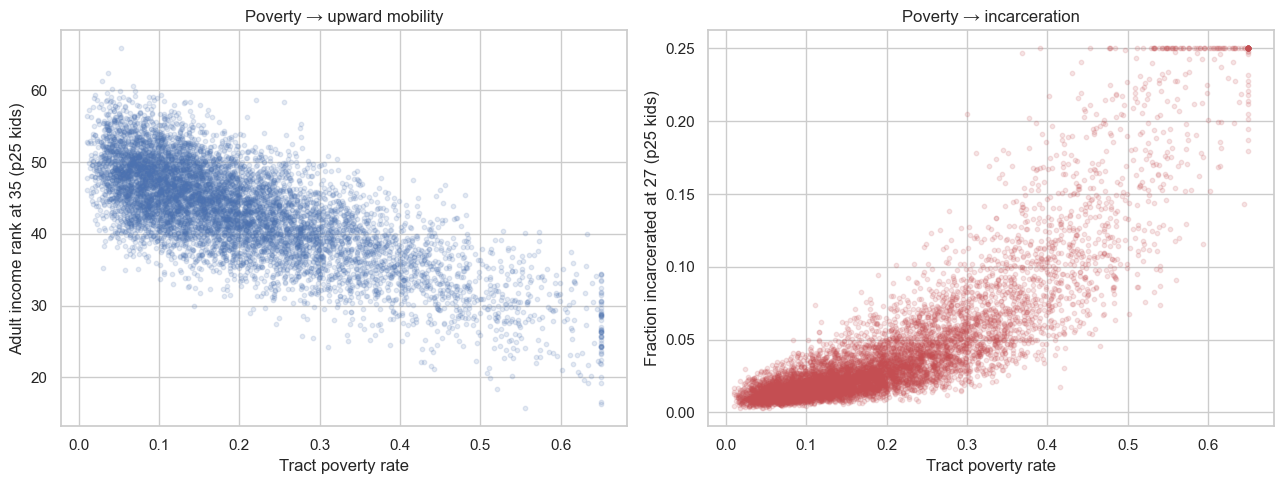

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sample = df.sample(n=min(8000, len(df)), random_state=2025)

axes[0].scatter(sample['poor_share'], sample['kfr_pooled_pooled_p25'],
                alpha=0.15, s=10, color='#4C72B0')
axes[0].set_xlabel('Tract poverty rate')
axes[0].set_ylabel('Adult income rank at 35 (p25 kids)')
axes[0].set_title('Poverty → upward mobility')

axes[1].scatter(sample['poor_share'], sample['jail_pooled_pooled_p25'].clip(upper=0.25),
                alpha=0.15, s=10, color='#C44E52')
axes[1].set_xlabel('Tract poverty rate')
axes[1].set_ylabel('Fraction incarcerated at 27 (p25 kids)')
axes[1].set_title('Poverty → incarceration')

plt.tight_layout()
plt.savefig(ROOT / 'docs' / 'fig_poverty_outcomes.png', dpi=120, bbox_inches='tight')
plt.show()

## Summary and next steps

This EDA establishes:

1. The dataset contains ~72,000 US census tracts with 19 socioeconomic features plus two outcomes.
2. Outcome distributions match published Opportunity Atlas marginals.
3. A few columns (school quality, rent, single-parent share) have 3–8% missingness — addressed with iterative imputation in `src/preprocessing.py`.
4. Income, density, and rent have heavy right tails — addressed with winsorization.
5. The raw correlations already reveal the systemic story the project is designed to quantify: tract-level poverty and family structure are strong predictors of children's adult outcomes.

The next notebook (`02_preprocessing_impact.ipynb`) quantifies the value of each preprocessing step.